In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import os
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
file_path = r"D:\Programs\supply_chain_ai\data\DataCoSupplyChainDataset.csv"
df = pd.read_csv(file_path, encoding = "latin1")
print("Dataset Shape : ", df.shape)
df.head()

Dataset Shape :  (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## Data Preprocessing

In [6]:
df.rename(columns={
    "Late_delivery_risk": "late_delivery_risk",
    "Order City": "origin_city",
    "Latitude": "origin_lat",
    "Longitude": "origin_lon",
    "Order Region": "order_region",
    "Shipping Mode": "shipping_mode",
    "Days for shipping (real)": "days_shipping_real",
    "Days for shipment (scheduled)": "days_shipping_scheduled",
    "Order Country": "order_country"
}, inplace = True)

cols_needed = [
    "origin_city", "origin_lat", "origin_lon",
    "order_region", "order_country", "shipping_mode",
    "days_shipping_real", "days_shipping_scheduled",
    "late_delivery_risk"
]

cols_available = [c for c in cols_needed if c in df.columns]
df = df[cols_available].copy()

df.dropna(subset=["origin_lat", "origin_lon", "late_delivery_risk"], inplace=True)

print("New Dataset Shape : ",df.shape)
print("Null Values Count :\n",df.isnull().sum())
print(f"Delay rate (overall): {df["late_delivery_risk"].mean():.3f}")

New Dataset Shape :  (180519, 9)
Null Values Count :
 origin_city                0
origin_lat                 0
origin_lon                 0
order_region               0
order_country              0
shipping_mode              0
days_shipping_real         0
days_shipping_scheduled    0
late_delivery_risk         0
dtype: int64
Delay rate (overall): 0.548


## Feature Engineering

In [7]:
df["delay_days"] = df["days_shipping_real"] - df["days_shipping_scheduled"]
df["delay_minutes"] = df["delay_days"] * 24 * 60
print(f"Average delay: {df["delay_minutes"].mean():.1f} minutes")
print(f"Max delay: {df["delay_minutes"].max():.1f} minutes")
print(f"Shipments delayed : {(df["delay_minutes"] > 0).sum()} / {len(df)}")

Average delay: 814.8 minutes
Max delay: 5760.0 minutes
Shipments delayed : 103400 / 180519


## Zone Clustering

In [8]:
city_stats = df.groupby("origin_city").agg(
    city_delay_rate=("late_delivery_risk", "mean"),
    lat=("origin_lat", "mean"),
    lon=("origin_lon", "mean"),
    shipment_count=("late_delivery_risk", "count")
).reset_index()

city_stats = city_stats[city_stats["shipment_count"] >= 5].copy()
city_stats.head(10)

,origin_city,city_delay_rate,lat,lon,shipment_count
0,Aachen,0.444444,26.485086,-86.613289,63
2,Aalst,0.695652,29.075618,-84.551609,23
3,Aba,0.500000,31.633850,-91.331354,36
4,Abadan,0.454545,27.319769,-73.914199,33
5,Abakaliki,0.000000,18.242300,-66.370510,6
6,Abbeville,0.416667,23.439767,-83.680167,12
7,Abbotsford,0.555556,42.465293,-100.534396,9
8,Abeokuta,0.466667,31.899578,-84.812916,15
9,Aberdeen,0.619048,26.576659,-86.137365,21
10,Abha,0.363636,24.536356,-70.234767,22


## Elbow Method

In [12]:
X_cluster = city_stats[["lat","lon","city_delay_rate"]]

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

wcss = []
k_range = range(2,15)

for k_val in k_range:
    km = KMeans(n_clusters = k_val , random_state = 42 , n_init = 10)
    km.fit(X_cluster_scaled)
    wcss.append(km.inertia_)

knee = KneeLocator(k_range,wcss,curve="convex",direction = "decreasing")
optimal_k = knee.elbow

print("Optimal K :",optimal_k)

Optimal K : 6


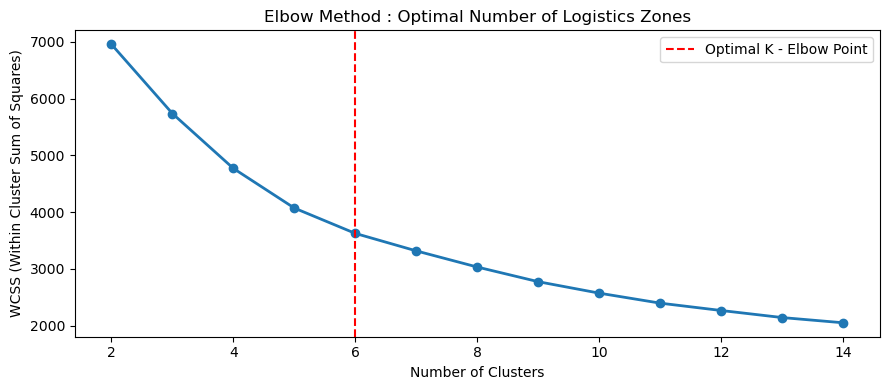

In [13]:
plt.figure(figsize = (9,4))
plt.plot(k_range,wcss,marker="o",linewidth=2)
plt.axvline(x=optimal_k,color = "red",linestyle="--",label="Optimal K - Elbow Point")
plt.title("Elbow Method : Optimal Number of Logistics Zones")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS (Within Cluster Sum of Squares)")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
kmeans_model = KMeans(n_clusters = optimal_k , random_state = 42 , n_init = 10)
city_stats["zone_id"] = kmeans_model.fit_predict(X_cluster_scaled)

zone_risk = city_stats.groupby("zone_id")["city_delay_rate"].mean().reset_index()
zone_risk.rename(columns={"city_delay_rate" : "zone_risk_score"}, inplace = True)

city_stats = pd.merge(city_stats,zone_risk,on="zone_id",how="left")

print("Zone summary:")
print(city_stats.groupby("zone_id").agg(
    cities=("origin_city", "count"),
    avg_delay_rate=("city_delay_rate", "mean"),
    zone_risk=("zone_risk_score", "first")
).round(3))

Zone summary:
         cities  avg_delay_rate  zone_risk
zone_id                                   
0          1389           0.528      0.528
1           488           0.791      0.791
2           228           0.725      0.725
3           374           0.206      0.206
4           289           0.240      0.240
5           440           0.792      0.792


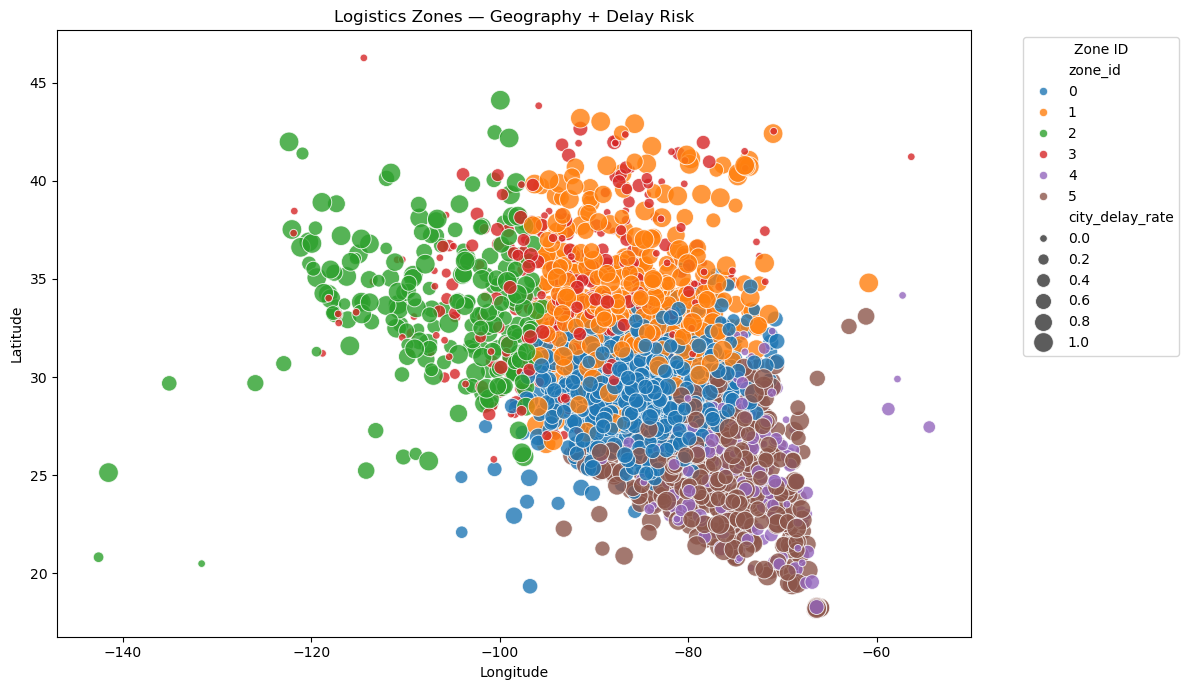

In [15]:
plt.figure(figsize=(12,7))
sns.scatterplot(
    data = city_stats,
    x="lon",
    y="lat",
    hue = "zone_id",
    size = "city_delay_rate",
    sizes = (30,200),
    palette = "tab10",
    alpha = 0.8
)
plt.title("Logistics Zones — Geography + Delay Risk")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Zone ID", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Merge Zone into the main dataframe

In [16]:
for col in ["zone_id_origin", "zone_risk_score"]:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)
df = pd.merge(
    df,
    city_stats[["origin_city", "zone_id", "zone_risk_score"]],
    on="origin_city",
    how="left"
)
df.rename(columns={"zone_id": "zone_id_origin"}, inplace=True)
assigned = df["zone_id_origin"].notna().sum()
print(f"Rows with zone assigned: {assigned} / {len(df)} ({assigned/len(df)*100:.1f}%)")
print(df[["origin_city", "zone_id_origin", "zone_risk_score"]].head(10))

Rows with zone assigned: 179451 / 180519 (99.4%)
  origin_city  zone_id_origin  zone_risk_score
0      Bekasi             0.0         0.527611
1     Bikaner             0.0         0.527611
2     Bikaner             0.0         0.527611
3  Townsville             0.0         0.527611
4  Townsville             0.0         0.527611
5   Toowoomba             0.0         0.527611
6   Guangzhou             0.0         0.527611
7   Guangzhou             0.0         0.527611
8   Guangzhou             0.0         0.527611
9   Guangzhou             0.0         0.527611


In [18]:
if "shipping_mode" in df.columns:
    mode_map = {
        "Standard Class": 0,
        "Second Class": 1,
        "First Class": 2,
        "Same Day": 3
    }
    df["shipping_mode_encoded"] = df["shipping_mode"].map(mode_map)
    df["shipping_mode_encoded"].fillna(0, inplace=True)
print("Shipping mode distribution :")
print(df["shipping_mode"].value_counts())

Shipping mode distribution :
shipping_mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64


## Congestion Score

In [19]:
# faster shipping modes = higher congestion zones
# This is a reasonable proxy -> express freight corridors are busier
def compute_congestion(row) :
    base = {0: 0.3,1: 0.45, 2: 0.6, 3 : 0.8}.get(
        row.get("shipping_mode_encoded",0), 0.3
    )
    zone_factor = row.get("zone_risk_score",0.5)*0.2
    return round(min(base+zone_factor,1.0),3)
df["congestion_score"] = df.apply(compute_congestion,axis = 1)
print(f"Congestion score stats:")
print(df["congestion_score"].describe().round(3))

Congestion score stats:
count    179451.000
mean          0.512
std           0.150
min           0.341
25%           0.406
50%           0.406
75%           0.556
max           0.958
Name: congestion_score, dtype: float64


## Anomaly detection - Isolation Forest

In [21]:
anomaly_features = ["days_shipping_real", "days_shipping_scheduled", 
                    "zone_risk_score", "congestion_score"]
df_anomaly = df[anomaly_features].dropna()

scaler_anomaly = StandardScaler()
X_anomaly_scaled = scaler_anomaly.fit_transform(df_anomaly)

iso_forest = IsolationForest(
    n_estimators = 100,
    contamination = 0.05,
    random_state = 42
)
iso_forest.fit(X_anomaly_scaled)

predictions = iso_forest.predict(X_anomaly_scaled)
df.loc[df_anomaly.index, "anomaly_flag"] = (predictions == -1).astype(int)
df["anomaly_flag"].fillna(0, inplace = True)
df["anomaly_flag"] = df["anomaly_flag"].astype(int)

n_anomalies = df["anomaly_flag"].sum()
print(f"Anomalies detected: {n_anomalies} / {len(df)} ({n_anomalies/len(df)*100:.1f}%)")
print("\nAnomaly vs delay rate:")
print(df.groupby("anomaly_flag")["late_delivery_risk"].mean().round(3))

Anomalies detected: 8333 / 180519 (4.6%)

Anomaly vs delay rate:
anomaly_flag
0    0.542
1    0.680
Name: late_delivery_risk, dtype: float64


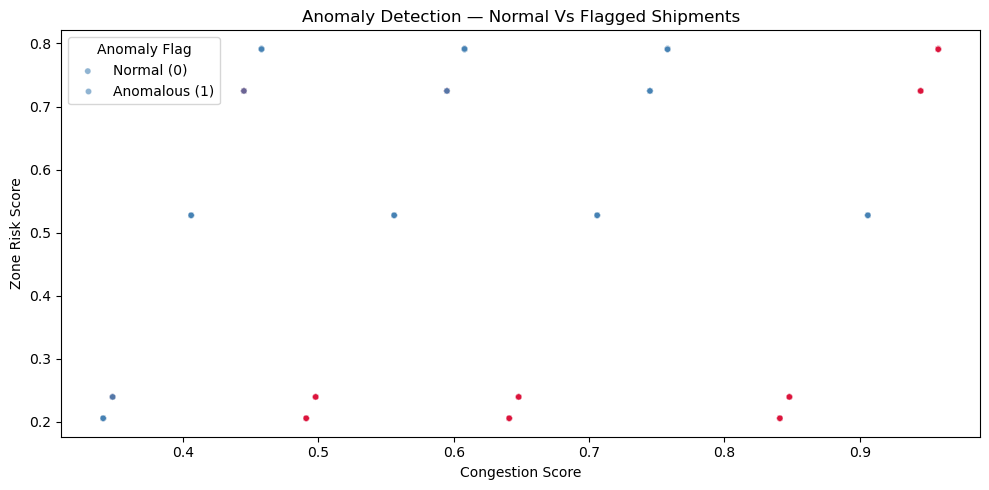

In [24]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    data = df,
    x = "congestion_score",
    y = "zone_risk_score",
    hue = "anomaly_flag",
    palette = {0: "steelblue", 1: "crimson"},
    alpha = 0.6,
    s=20
)
plt.title("Anomaly Detection — Normal Vs Flagged Shipments")
plt.xlabel("Congestion Score")
plt.ylabel("Zone Risk Score")
plt.legend(title="Anomaly Flag", labels=["Normal (0)", "Anomalous (1)"])
plt.tight_layout()
plt.show()

In [26]:
feature_cols = [
    "days_shipping_scheduled",
    "shipping_mode_encoded",
    "zone_id_origin",
    "zone_risk_score",
    "congestion_score",
    "anomaly_flag",
    "late_delivery_risk",
    "delay_minutes"
]

df_model = df[feature_cols].dropna().copy()
print(f"Final dataset shape for modelling: {df_model.shape}")
print(f"\nFeature stats:")
print(df_model.describe().round(3))
print(f"\nClass balance (late_delivery_risk):")
print(df_model["late_delivery_risk"].value_counts(normalize=True).round(3))

Final dataset shape for modelling: (179451, 8)

Feature stats:
       days_shipping_scheduled  shipping_mode_encoded  zone_id_origin  \
count               179451.000             179451.000      179451.000   
mean                     2.932                  0.665           0.622   
std                      1.374                  0.924           1.399   
min                      0.000                  0.000           0.000   
25%                      2.000                  0.000           0.000   
50%                      4.000                  0.000           0.000   
75%                      4.000                  1.000           0.000   
max                      4.000                  3.000           5.000   

       zone_risk_score  congestion_score  anomaly_flag  late_delivery_risk  \
count       179451.000        179451.000    179451.000          179451.000   
mean             0.544             0.512         0.046               0.548   
std              0.126             0.150     

## Saving the processed dataset

In [27]:
output_path = r"D:\Programs\supply_chain_ai\data\processed_dataset.csv"
df_model.to_csv(output_path, index=False)
print(f"Saved processed dataset: {df_model.shape}")

models_dir = r"D:\Programs\supply_chain_ai\backend\app\ml"
os.makedirs(models_dir, exist_ok=True)

joblib.dump(kmeans_model, os.path.join(models_dir, "kmeans_model.joblib"))
joblib.dump(scaler, os.path.join(models_dir, "kmeans_scaler.joblib"))
joblib.dump(iso_forest, os.path.join(models_dir, "isolation_forest.joblib"))
joblib.dump(scaler_anomaly, os.path.join(models_dir, "anomaly_scaler.joblib"))

city_zone_lookup = city_stats[["origin_city", "zone_id", "zone_risk_score"]].copy()
city_zone_lookup.to_csv(
    os.path.join(models_dir, "city_zone_lookup.csv"), 
    index=False
)
print("Done")

Saved processed dataset: (179451, 8)
Done
